In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df1 = pd.read_csv('/content/country_metadata.csv')
    df2 = pd.read_csv('/content/country_year_indicators.csv')
    df3 = pd.read_csv('/content/economic_stress_score.csv')
    df4 = pd.read_csv('/content/indicator_dictionary.csv')

    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the files are uploaded to the Colab environment.")

Datasets loaded successfully.


In [4]:
display(df1.head())
display(df2.head())
display(df3.head())
display(df4.head())

,country_code,country_name,iso3,region,income_group,latitude,longitude
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,12.51670,-70.0167
1,AFG,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,34.52280,69.1761
2,AGO,Angola,AGO,Sub-Saharan Africa,Lower middle income,-8.81155,13.2420
3,ALB,Albania,ALB,Europe & Central Asia,Upper middle income,41.33170,19.8172
4,AND,Andorra,AND,Europe & Central Asia,High income,42.50750,1.5218


,country_code,country_name,iso3,region,income_group,year,gdp_growth,inflation,unemployment,gdp_per_capita,population,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score,data_completeness_score
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,1960,NaN,NaN,NaN,NaN,54922.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,1961,NaN,NaN,NaN,NaN,55578.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,1962,NaN,NaN,NaN,NaN,56320.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,1963,NaN,NaN,NaN,NaN,57002.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,1964,NaN,NaN,NaN,NaN,57619.0,NaN,NaN,NaN,11.1111,NaN,NaN,0.0


,country_code,country_name,year,region,income_group,inflation_score,unemployment_score,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score,stress_category
0,ABW,Aruba,1960,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,1961,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,1962,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,1963,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,1964,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,column_name,indicator_name,source,source_indicator_code,unit,description,higher_value_interpretation,missing_value_notes
0,country_code,Country code,World Bank,ISO3/country id,text,Three-letter country code used for joins.,Identifier only.,Required for published rows.
1,country_name,Country name,World Bank,country metadata,text,Official country/economy name from World Bank ...,Identifier only.,Required for published rows.
2,iso3,ISO3,World Bank,country metadata,text,ISO3 country code where available.,Identifier only.,Mirrors country_code for World Bank countries.
3,region,Region,World Bank,country metadata,text,World Bank region group.,Used for comparison.,Aggregates are excluded from the main dataset.
4,income_group,Income group,World Bank,country metadata,text,World Bank income classification.,Used for comparison.,Aggregates are excluded from the main dataset.


In [5]:
import pandas as pd

merge_cols = ['country_code', 'country_name', 'year', 'region']

time_series_merged = pd.merge(
    df2,
    df3,
    on=merge_cols,
    how='outer'
)
super_dataset = pd.merge(
    time_series_merged,
    df1,
    on=['country_code', 'country_name', 'iso3'],
    how='left'
)

print(f"Super dataset created with shape: {super_dataset.shape}")
display(super_dataset.head())

Super dataset created with shape: (14322, 30)


,country_code,country_name,iso3,region_x,income_group_x,year,gdp_growth,inflation,unemployment,gdp_per_capita,...,unemployment_score,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score,stress_category,region_y,income_group,latitude,longitude
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,1960,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Latin America & Caribbean,High income,12.5167,-70.0167
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,1961,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Latin America & Caribbean,High income,12.5167,-70.0167
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,1962,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Latin America & Caribbean,High income,12.5167,-70.0167
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,1963,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Latin America & Caribbean,High income,12.5167,-70.0167
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,1964,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Latin America & Caribbean,High income,12.5167,-70.0167


In [6]:
missing_stats = super_dataset.isnull().sum()
missing_percent = (super_dataset.isnull().sum() / len(super_dataset)) * 100

null_summary = pd.DataFrame({
    'Missing Values': missing_stats,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("Missing Value Statistics:")
display(null_summary[null_summary['Missing Values'] > 0])

Missing Value Statistics:


,Missing Values,Percentage (%)
dietary_energy_supply_adequacy,10491,73.250943
unemployment,7791,54.398827
unemployment_score,7791,54.398827
inflation_score,5351,37.362100
inflation,5351,37.362100
cereal_yield,3992,27.873202
cereal_production_tonnes,3942,27.524089
food_production_index,3311,23.118280
gdp_growth_score,3108,21.700880
gdp_growth,3108,21.700880


In [8]:
cleaned_df = super_dataset.sort_values(['country_code', 'year'])

numerical_cols = cleaned_df.select_dtypes(include=[np.number]).columns
cleaned_df[numerical_cols] = cleaned_df.groupby('country_code')[numerical_cols].ffill().bfill()

cleaned_df[numerical_cols] = cleaned_df[numerical_cols].fillna(cleaned_df[numerical_cols].median())

categorical_cols = cleaned_df.select_dtypes(exclude=[np.number]).columns
cleaned_df[categorical_cols] = cleaned_df[categorical_cols].fillna('Unknown')

super_dataset = cleaned_df
print("Missing values handled. New null count:", super_dataset.isnull().sum().sum())
display(super_dataset.head())

Missing values handled. New null count: 0


,country_code,country_name,iso3,region_x,income_group_x,year,gdp_growth,inflation,unemployment,gdp_per_capita,...,unemployment_score,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score,stress_category,region_y,income_group,latitude,longitude
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,1960,16.078431,4.032258,7.972,6767.559229,...,61.497326,1.169591,22.619048,42.936264,32.77,Unknown,Latin America & Caribbean,High income,12.5167,-70.0167
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,1961,16.078431,4.032258,7.972,6767.559229,...,61.497326,1.169591,22.619048,42.936264,32.77,Unknown,Latin America & Caribbean,High income,12.5167,-70.0167
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,1962,16.078431,4.032258,7.972,6767.559229,...,61.497326,1.169591,22.619048,42.936264,32.77,Unknown,Latin America & Caribbean,High income,12.5167,-70.0167
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,1963,16.078431,4.032258,7.972,6767.559229,...,61.497326,1.169591,22.619048,42.936264,32.77,Unknown,Latin America & Caribbean,High income,12.5167,-70.0167
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,1964,16.078431,4.032258,7.972,6767.559229,...,61.497326,1.169591,22.619048,42.936264,32.77,Unknown,Latin America & Caribbean,High income,12.5167,-70.0167


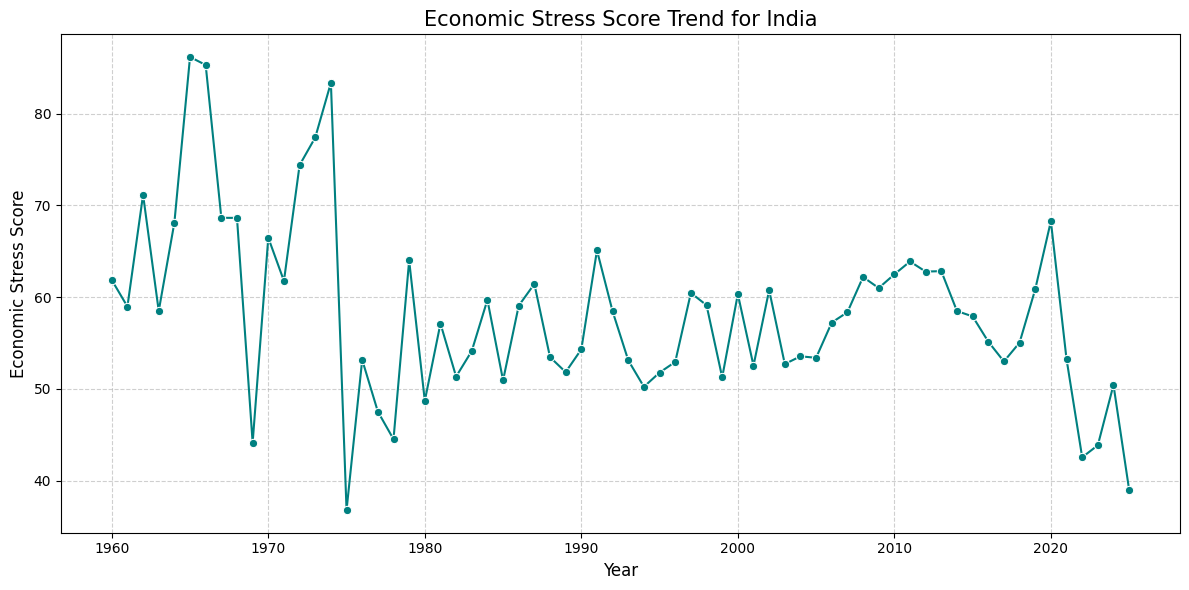

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a country for visualization
selected_country = 'India'

# Filter the dataset
country_trend = super_dataset[super_dataset['country_name'] == selected_country].sort_values('year')

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=country_trend, x='year', y='economic_stress_score', marker='o', color='teal')

plt.title(f'Economic Stress Score Trend for {selected_country}', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Economic Stress Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Average Economic Stress Score by Region:


,region_x,economic_stress_score
0,Sub-Saharan Africa,59.645581
1,South Asia,53.911237
2,"Middle East, North Africa, Afghanistan & Pakistan",52.542233
3,Latin America & Caribbean,47.017309
4,Europe & Central Asia,45.060925
5,East Asia & Pacific,43.651626
6,North America,35.800909


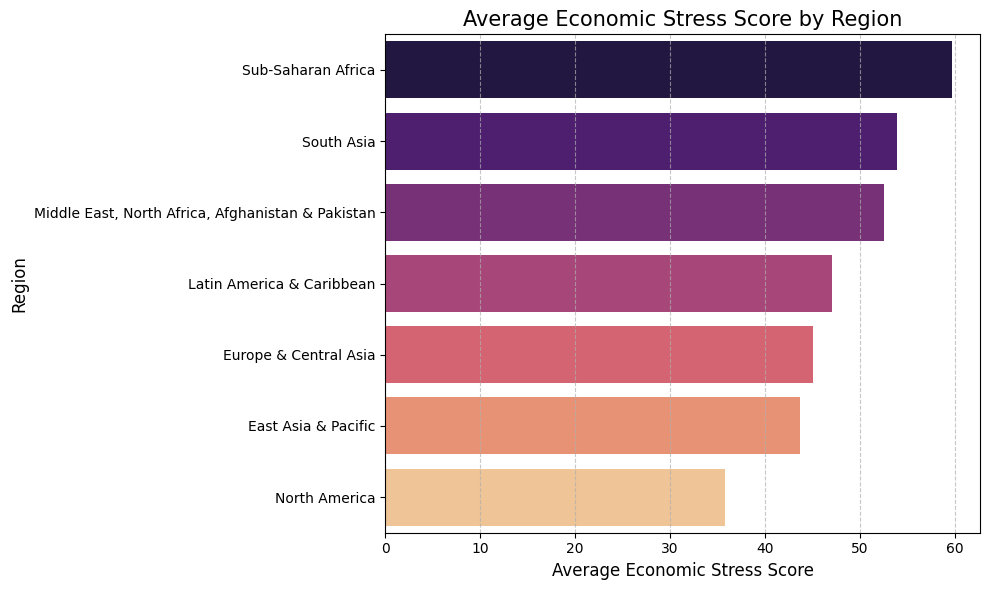

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average economic stress score by region
regional_stress = super_dataset.groupby('region_x')['economic_stress_score'].mean().sort_values(ascending=False).reset_index()

print("Average Economic Stress Score by Region:")
display(regional_stress)

# Visualize the results
plt.figure(figsize=(10, 6))
# Fixed warning by assigning y to hue and setting legend=False
sns.barplot(data=regional_stress, x='economic_stress_score', y='region_x', hue='region_x', palette='magma', legend=False)

plt.title('Average Economic Stress Score by Region', fontsize=15)
plt.xlabel('Average Economic Stress Score', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

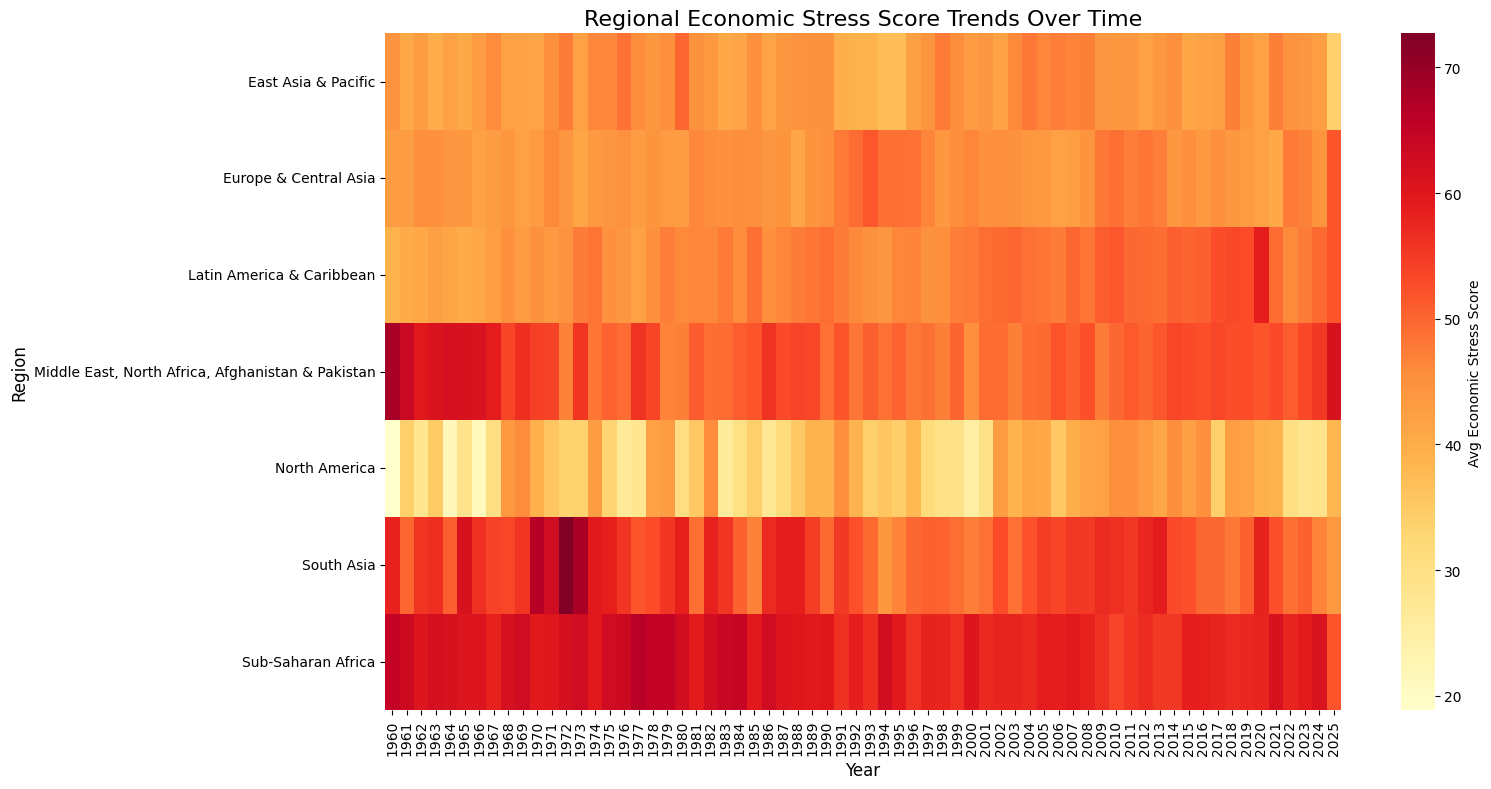

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data by region and year
heatmap_data = super_dataset.groupby(['region_x', 'year'])['economic_stress_score'].mean().reset_index()

# Pivot for heatmap format (Regions as rows, Years as columns)
heatmap_pivot = heatmap_data.pivot(index='region_x', columns='year', values='economic_stress_score')

# Plotting
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Avg Economic Stress Score'})

plt.title('Regional Economic Stress Score Trends Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

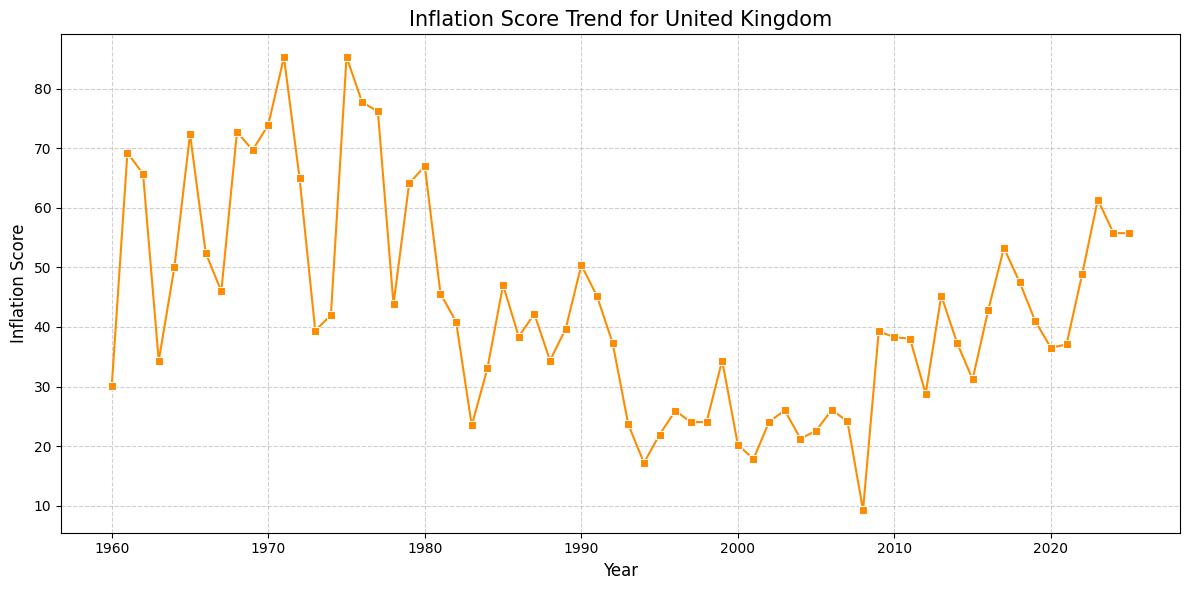

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a different country for comparison
selected_country_comparison = 'United Kingdom'

# Filter the dataset for the selected country
comparison_trend = super_dataset[super_dataset['country_name'] == selected_country_comparison].sort_values('year')

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=comparison_trend, x='year', y='inflation_score', marker='s', color='darkorange')

plt.title(f'Inflation Score Trend for {selected_country_comparison}', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

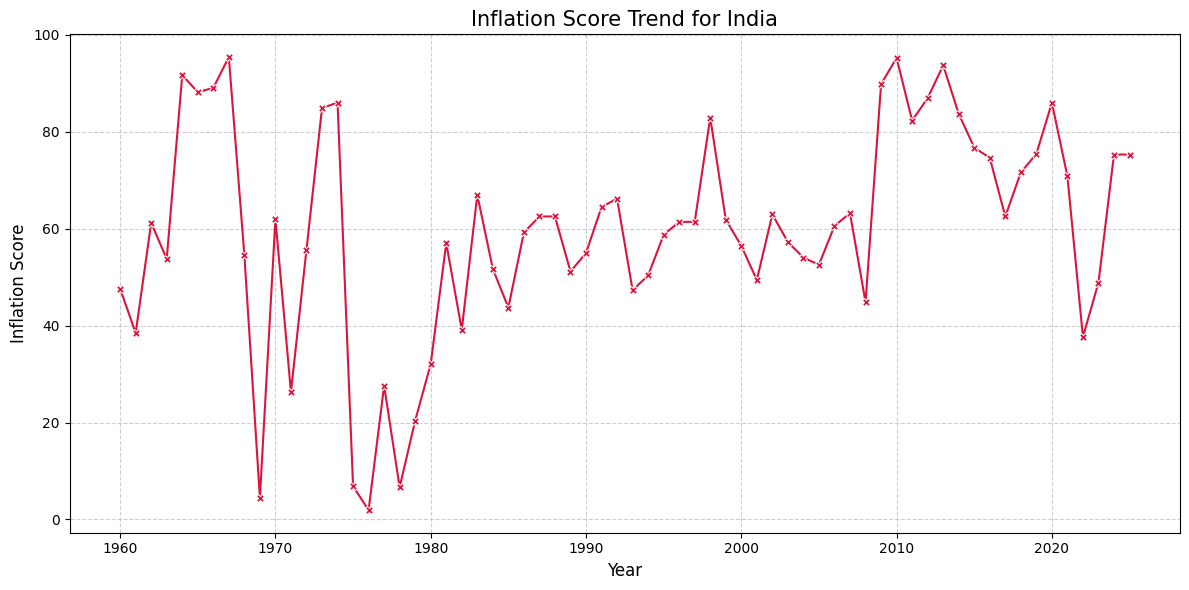

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a different country for comparison
selected_country_new = 'India'

# Filter the dataset for the selected country
new_comparison_trend = super_dataset[super_dataset['country_name'] == selected_country_new].sort_values('year')

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=new_comparison_trend, x='year', y='inflation_score', marker='X', color='crimson')

plt.title(f'Inflation Score Trend for {selected_country_new}', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Part 1: Clustering and Segmentation
We will use K-Means clustering to group countries based on their macroeconomic indicators (GDP growth, Inflation, Unemployment, and Food Pressure). This helps identify 'peer' economies.

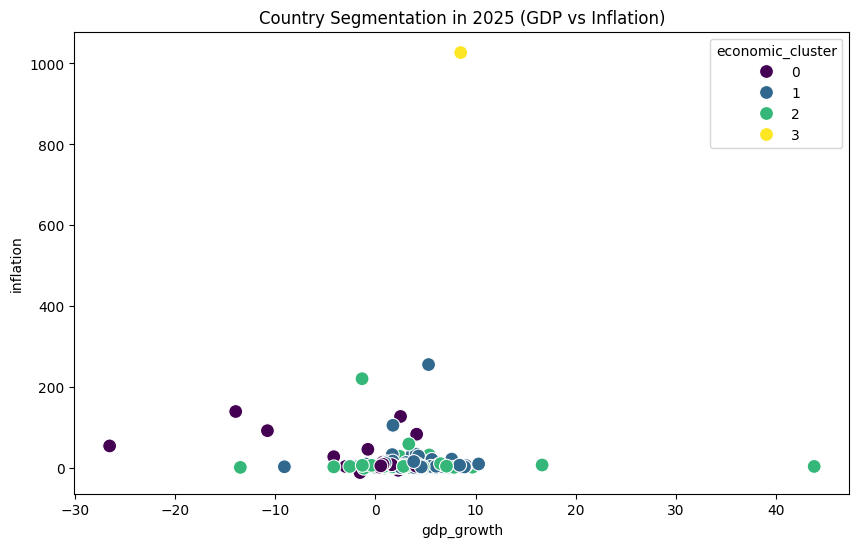

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Selecting features for clustering (latest year only for a snapshot)
latest_year = super_dataset['year'].max()
cluster_data = super_dataset[super_dataset['year'] == latest_year].copy()

features = ['gdp_growth', 'inflation', 'unemployment', 'food_pressure_score', 'income_vulnerability_score']
X = cluster_data[features]

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data['economic_cluster'] = kmeans.fit_predict(X_scaled)

# Visualizing clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_data, x='gdp_growth', y='inflation', hue='economic_cluster', palette='viridis', s=100)
plt.title(f'Country Segmentation in {latest_year} (GDP vs Inflation)')
plt.show()

### Part 2: Feature Engineering & Importance
To understand what drives the `economic_stress_score`, we'll train a Random Forest Regressor and extract feature importance.

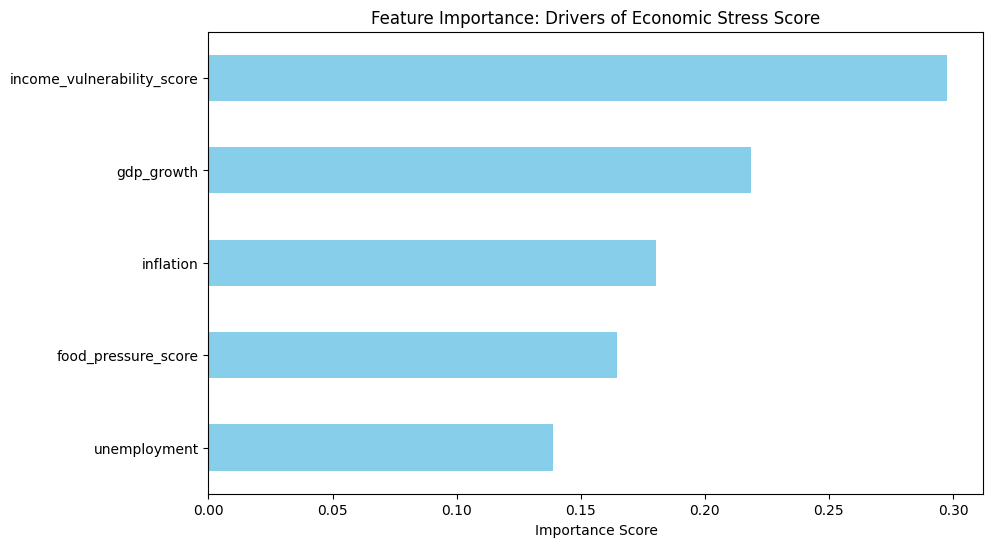

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Define features (X) and target (y)
X_ml = super_dataset[features]
y_ml = super_dataset['economic_stress_score']

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_ml, y_ml)

# Plot Feature Importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance: Drivers of Economic Stress Score')
plt.xlabel('Importance Score')
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV, train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialize Grid Search
rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit Grid Search
print("Starting Grid Search tuning...")
grid_search.fit(X_train, y_train)

# Output results
print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
print(f"Improved Model R^2 Score: {best_rf.score(X_test, y_test):.4f}")

Starting Grid Search tuning...
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Improved Model R^2 Score: 0.8410


In [19]:
import pickle

# Define the filename
model_filename = 'best_economic_stress_model.pkl'

# Save the model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf, file)

print(f"Model successfully saved as {model_filename}")

Model successfully saved as best_economic_stress_model.pkl


In [21]:
import pickle

# Load the model from the file
with open('best_economic_stress_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Verify by calculating the score on the test set
verification_score = loaded_model.score(X_test, y_test)
print(f"Loaded Model R^2 Score: {verification_score:.4f}")

# Run a sample prediction
sample_pred = loaded_model.predict(X_test.iloc[[0]])
print(f"Actual value: {y_test.iloc[0]:.2f}, Predicted value: {sample_pred[0]:.2f}")

Loaded Model R^2 Score: 0.8410
Actual value: 48.73, Predicted value: 49.91


In [23]:
def predict_custom_stress(gdp, infl, unemp, food, income):
    # Create a feature dataframe with the same column names used during training
    custom_input = pd.DataFrame([[gdp, infl, unemp, food, income]], columns=features)

    # Predict using the loaded model
    prediction = loaded_model.predict(custom_input)[0]
    return prediction

# --- Example Custom Input ---
# Modify these values to see different predictions
custom_gdp = 2.5
custom_inflation = 5.0
custom_unemployment = 8.0
custom_food_pressure = 45.0
custom_income_vulnerability = 30.0

result = predict_custom_stress(custom_gdp, custom_inflation, custom_unemployment, custom_food_pressure, custom_income_vulnerability)

print(f"Predicted Economic Stress Score for input: {result:.2f}")

Predicted Economic Stress Score for input: 52.65


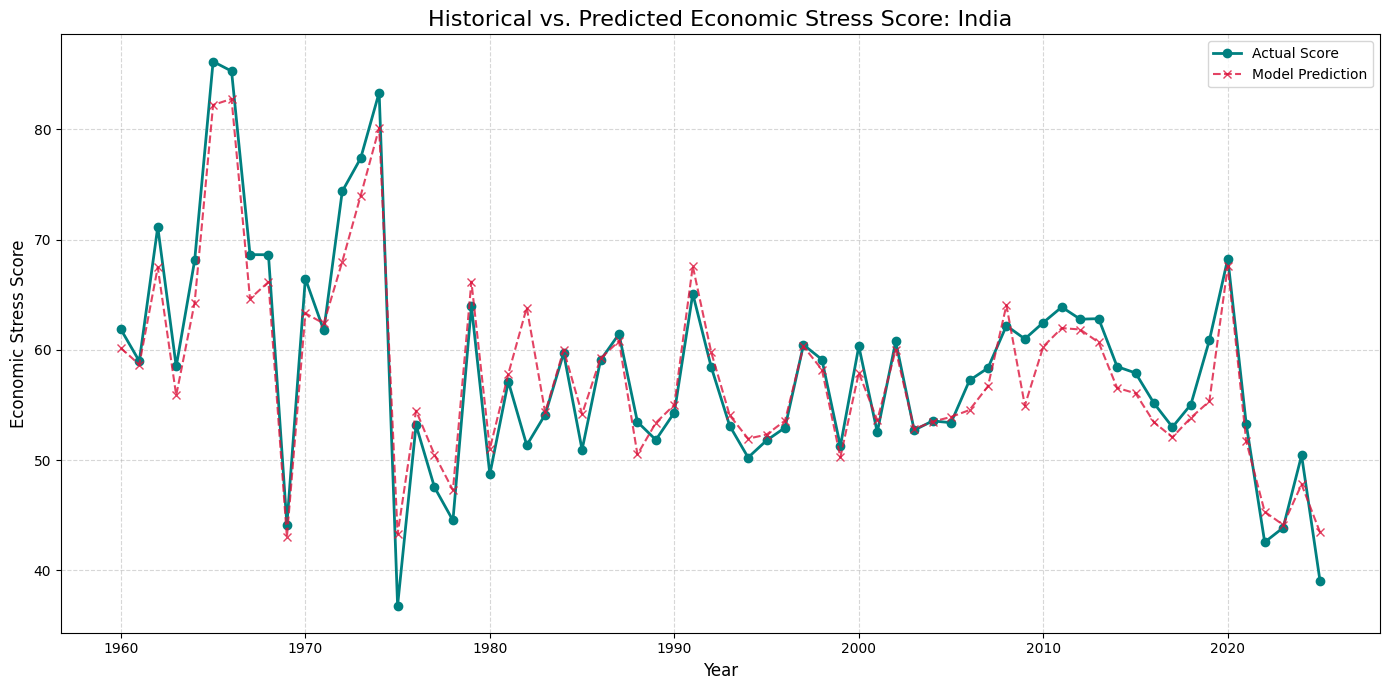

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select a country and its historical data
country_to_compare = 'India'
historical_data = super_dataset[super_dataset['country_name'] == country_to_compare].sort_values('year')

# 2. Extract features for the model
X_historical = historical_data[features]

# 3. Generate predictions using the loaded model
historical_data['predicted_stress_score'] = loaded_model.predict(X_historical)

# 4. Visualize Actual vs Predicted Trends
plt.figure(figsize=(14, 7))
plt.plot(historical_data['year'], historical_data['economic_stress_score'], label='Actual Score', color='teal', marker='o', linewidth=2)
plt.plot(historical_data['year'], historical_data['predicted_stress_score'], label='Model Prediction', color='crimson', linestyle='--', marker='x', alpha=0.8)

plt.title(f'Historical vs. Predicted Economic Stress Score: {country_to_compare}', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Economic Stress Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error

# Generate predictions for the test set
y_pred = loaded_model.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Absolute Error (MAE): 4.8623


In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

# Define the region to test
test_region = 'Sub-Saharan Africa'

# Filter the original super_dataset for this region and extract the test indices
# We align it with the existing X_test/y_test split
region_indices = super_dataset[super_dataset['region_x'] == test_region].index
test_indices_in_region = y_test.index.intersection(region_indices)

if len(test_indices_in_region) > 0:
    X_test_region = X_test.loc[test_indices_in_region]
    y_test_region = y_test.loc[test_indices_in_region]

    # Predict
    y_pred_region = loaded_model.predict(X_test_region)

    # Metrics
    region_mae = mean_absolute_error(y_test_region, y_pred_region)
    region_r2 = r2_score(y_test_region, y_pred_region)

    print(f"Performance Metrics for {test_region}:")
    print(f"Sample size: {len(test_indices_in_region)}")
    print(f"MAE: {region_mae:.4f}")
    print(f"R^2 Score: {region_r2:.4f}")
else:
    print(f"No samples found for region {test_region} in the test set.")

Performance Metrics for Sub-Saharan Africa:
Sample size: 647
MAE: 5.7485
R^2 Score: 0.7371


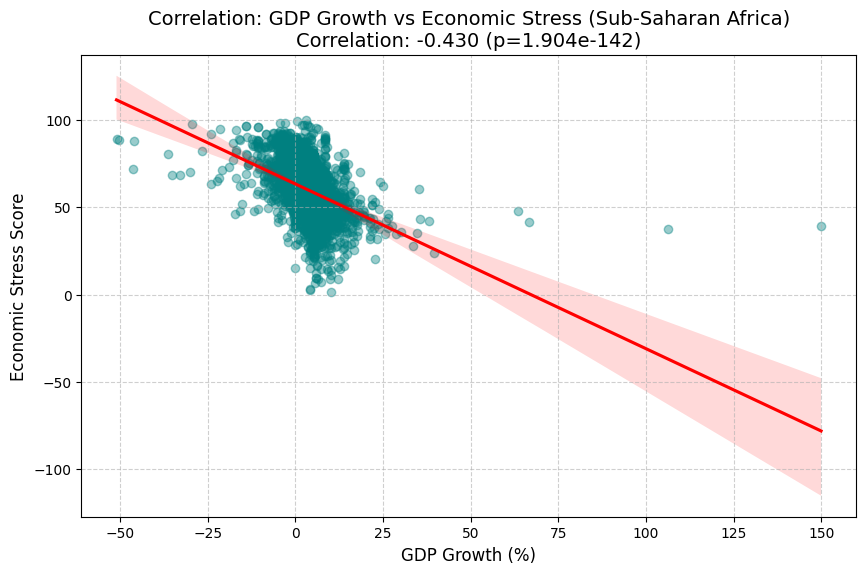

Pearson Correlation Coefficient: -0.4296
P-value: 0.0000


In [35]:
import scipy.stats as stats

# Filter for Sub-Saharan Africa
ssa_data = super_dataset[super_dataset['region_x'] == 'Sub-Saharan Africa']

# Calculate Pearson correlation
corr_coef, p_value = stats.pearsonr(ssa_data['gdp_growth'], ssa_data['economic_stress_score'])

# Visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(data=ssa_data, x='gdp_growth', y='economic_stress_score',
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})

plt.title(f'Correlation: GDP Growth vs Economic Stress (Sub-Saharan Africa)\nCorrelation: {corr_coef:.3f} (p={p_value:.3e})', fontsize=14)
plt.xlabel('GDP Growth (%)', fontsize=12)
plt.ylabel('Economic Stress Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4f}")

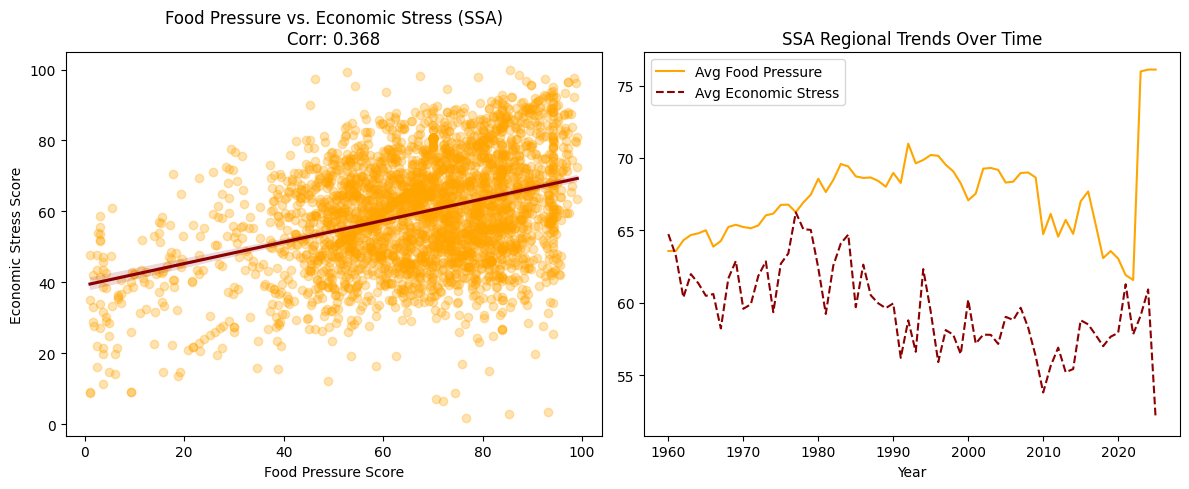

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Filter for Sub-Saharan Africa
ssa_data = super_dataset[super_dataset['region_x'] == 'Sub-Saharan Africa'].copy()

# Calculate correlation
corr, p_val = pearsonr(ssa_data['food_pressure_score'], ssa_data['economic_stress_score'])

# Plot 1: Scatter and Regression
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.regplot(data=ssa_data, x='food_pressure_score', y='economic_stress_score',
            scatter_kws={'alpha':0.3, 'color':'orange'}, line_kws={'color':'darkred'})
plt.title(f'Food Pressure vs. Economic Stress (SSA)\nCorr: {corr:.3f}')
plt.xlabel('Food Pressure Score')
plt.ylabel('Economic Stress Score')

# Plot 2: Historical Averages Comparison
ssa_yearly = ssa_data.groupby('year')[['food_pressure_score', 'economic_stress_score']].mean()

plt.subplot(1, 2, 2)
plt.plot(ssa_yearly.index, ssa_yearly['food_pressure_score'], label='Avg Food Pressure', color='orange')
plt.plot(ssa_yearly.index, ssa_yearly['economic_stress_score'], label='Avg Economic Stress', color='darkred', linestyle='--')
plt.title('SSA Regional Trends Over Time')
plt.xlabel('Year')
plt.legend()

plt.tight_layout()
plt.show()

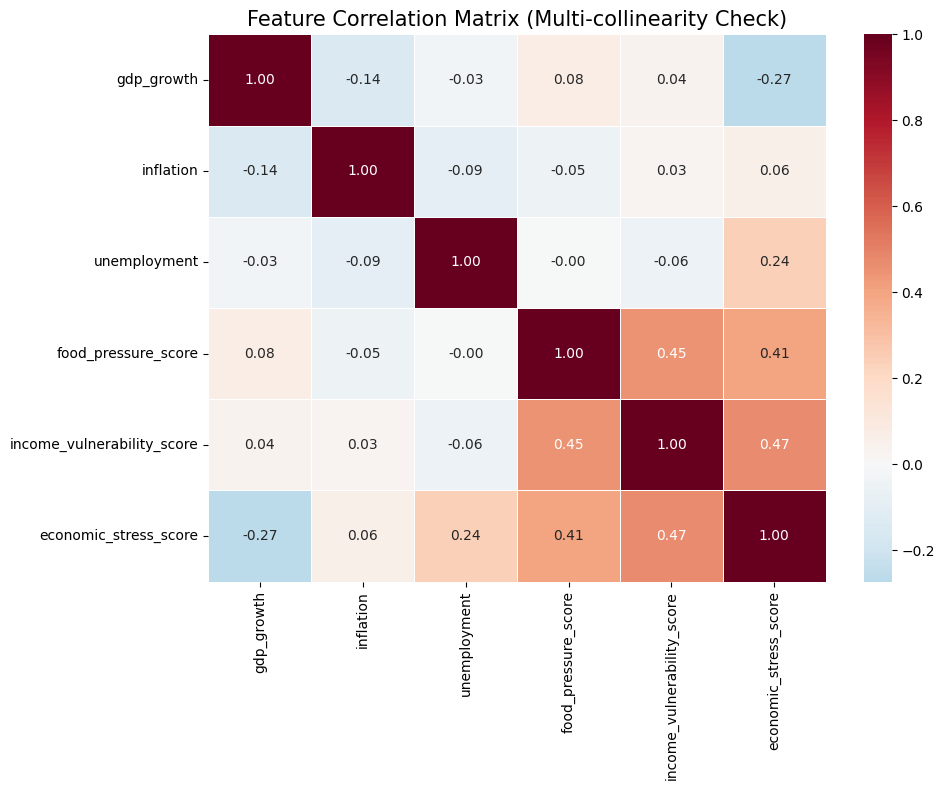

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the model features
# We'll include the target 'economic_stress_score' to see how features relate to it as well
corr_features = features + ['economic_stress_score']
correlation_matrix = super_dataset[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('Feature Correlation Matrix (Multi-collinearity Check)', fontsize=15)
plt.tight_layout()
plt.show()

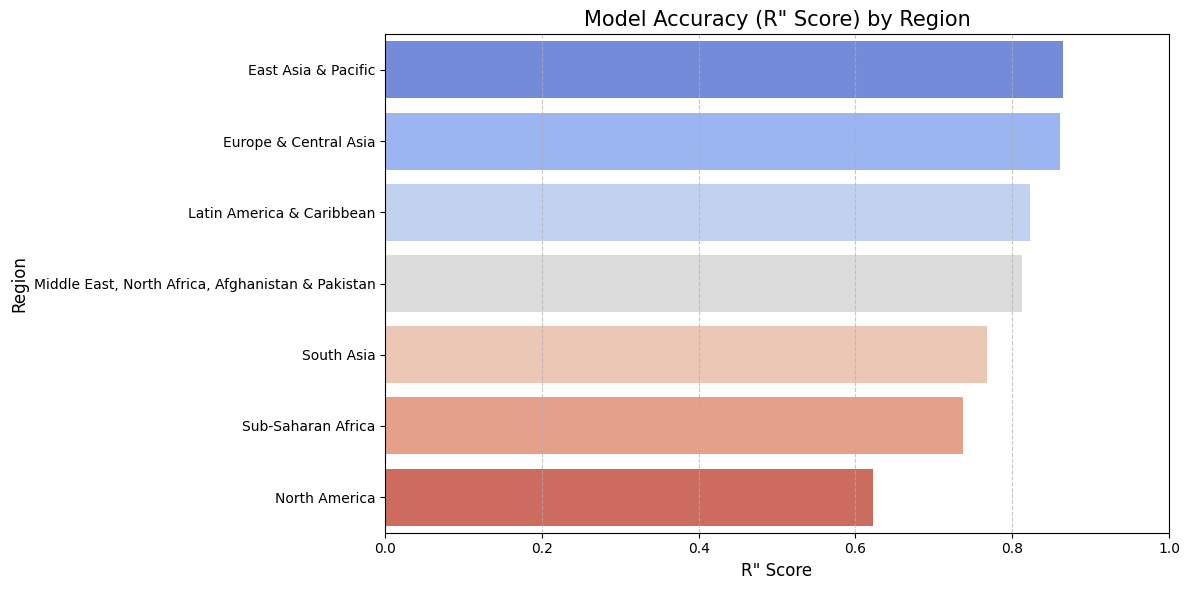

In [30]:
from sklearn.metrics import r2_score

region_results = []
unique_regions = super_dataset['region_x'].unique()

for region in unique_regions:
    # Find indices for this region that are also in the test set
    region_indices = super_dataset[super_dataset['region_x'] == region].index
    test_indices_in_region = y_test.index.intersection(region_indices)

    if len(test_indices_in_region) > 5: # Ensure a minimum sample size for a meaningful R2
        X_reg = X_test.loc[test_indices_in_region]
        y_reg = y_test.loc[test_indices_in_region]

        r2 = r2_score(y_reg, loaded_model.predict(X_reg))
        region_results.append({'Region': region, 'R2_Score': r2})

# Convert to DataFrame for plotting
region_perf_df = pd.DataFrame(region_results).sort_values(by='R2_Score', ascending=False)

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=region_perf_df, x='R2_Score', y='Region', hue='Region', palette='coolwarm', legend=False)
plt.title('Model Accuracy (R" Score) by Region', fontsize=15)
plt.xlabel('R" Score', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.xlim(0, 1) # R2 usually between 0 and 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

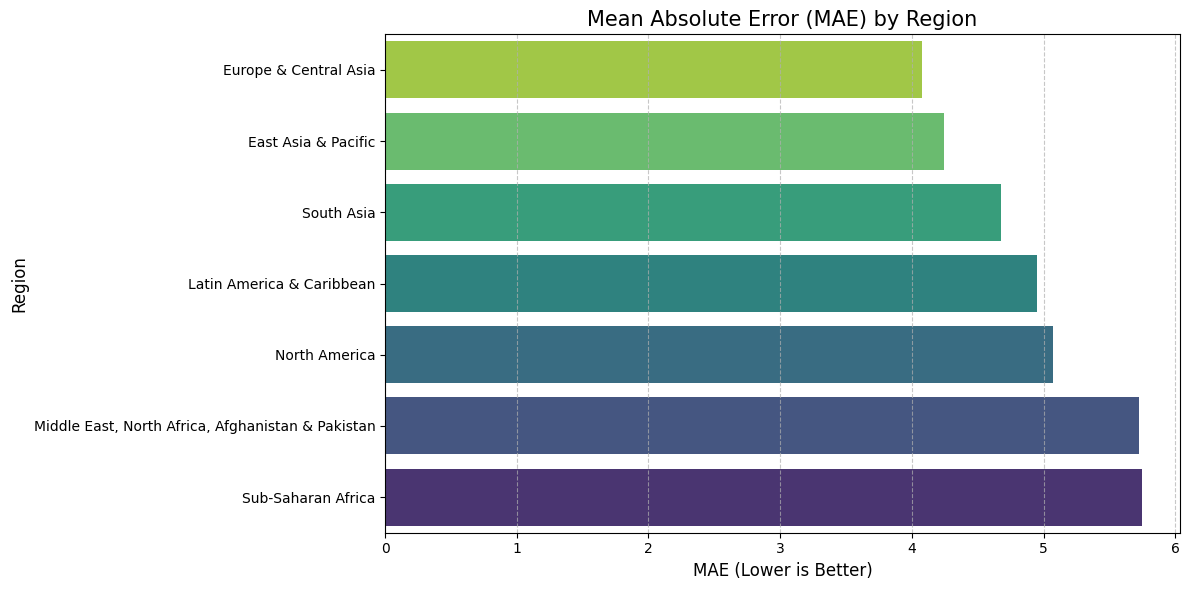

,Region,MAE
3,Europe & Central Asia,4.076011
4,East Asia & Pacific,4.245068
5,South Asia,4.674425
0,Latin America & Caribbean,4.947803
6,North America,5.069026
1,"Middle East, North Africa, Afghanistan & Pakistan",5.726188
2,Sub-Saharan Africa,5.748545


In [31]:
from sklearn.metrics import mean_absolute_error

region_mae_results = []

for region in unique_regions:
    # Find indices for this region that are also in the test set
    region_indices = super_dataset[super_dataset['region_x'] == region].index
    test_indices_in_region = y_test.index.intersection(region_indices)

    if len(test_indices_in_region) > 0:
        X_reg = X_test.loc[test_indices_in_region]
        y_reg = y_test.loc[test_indices_in_region]

        # Calculate MAE for the region
        mae_val = mean_absolute_error(y_reg, loaded_model.predict(X_reg))
        region_mae_results.append({'Region': region, 'MAE': mae_val})

# Convert to DataFrame and sort by MAE (lower is better)
region_mae_df = pd.DataFrame(region_mae_results).sort_values(by='MAE')

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=region_mae_df, x='MAE', y='Region', hue='Region', palette='viridis_r', legend=False)
plt.title('Mean Absolute Error (MAE) by Region', fontsize=15)
plt.xlabel('MAE (Lower is Better)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(region_mae_df)